<a href="https://colab.research.google.com/github/samuelrosendo/DTWIN-FV-UFAL/blob/main/REAJUSTE_NO_COD_PIBIC_DTWIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from google.colab import drive #importando dados do google drive
drive.mount('/content/drive') #caminho para acessar até os arquivos do google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# Caminho da pasta com os arquivos.dat
pasta = r"/content/drive/MyDrive/Colab Notebooks/PIBIC - SAMUEL ROSENDO/JAN -2025/janeiro - Copia"

# Cria uma lista com todos os arquivos .dat dentro da pasta
arquivos = [
    os.path.join(pasta, arquivo)
    for arquivo in os.listdir(pasta)
    if arquivo.endswith('.dat') and os.path.isfile(os.path.join(pasta, arquivo))
]

# Cria um DataFrame vazio para acumular os dados
dfs = [] # Initialize the list to store dataframes

# Percorre cada arquivo encontrado e junta todos os dados
for arquivo in arquivos:
    df_temp = pd.read_csv(
        os.path.join(pasta, arquivo),
        sep=",", # Changed separator to comma
        header=1 # Added header parameter
    )
    dfs.append(df_temp)

tabela_final = pd.concat(dfs, ignore_index=True)

# Remove aspas dos nomes das colunas, similar to previous successful loads
tabela_final.columns = tabela_final.columns.str.replace('"', '')

# Convert the 'TMSTAMP' column to datetime and set as index
tabela_final['TMSTAMP'] = pd.to_datetime(tabela_final['TMSTAMP'])
tabela_final = tabela_final.set_index("TMSTAMP")

tabela_final = tabela_final.drop("RECNBR", axis=1)



In [3]:
# =========================================================
# REMOÇÃO DE HORÁRIOS SEM GERAÇÃO + RADIAÇÃO ZERO
# =========================================================
df = tabela_final.copy()

df = df.between_time("05:30", "17:30")
#df = df[df["Radiacao_Avg"] > 0]

# print(df.index.time.min())
# print(df.index.time.max())

# display(df.head(100))
# display(df.tail(20))

In [4]:
# =========================================================
# PARÂMETROS DO SISTEMA FOTOVOLTAICO
# =========================================================
P_mod = 270              # W
H_STC = 1000             # W/m²
T_STC = 25               # °C
gamma_mp = -0.004        # 1/°C

beta = -0.0030           # V/°C

V_MPP_STC  = 31.7        # V
V_MPP_NOTC = 29.0        # V
I_MPP_STC  = 8.52        # A
I_MPP_NOTC = 6.97       # A

n_mod_stg1 = 9
n_mod_stg2 = 10


In [5]:
# =========================================================
# MODELO CC - STC
# =========================================================
df["V_mpp_STC"] = V_MPP_STC + (beta * (df["Temp_Cel_Avg"] - T_STC))
df["I_mpp_STC"] = (df["Radiacao_Avg"] * I_MPP_STC) / H_STC

df["Pmp_STG1_STC"] = df["I_mpp_STC"] * (n_mod_stg1 * df["V_mpp_STC"])
df["Pmp_STG2_STC"] = df["I_mpp_STC"] * (n_mod_stg2 * df["V_mpp_STC"])

#display(df.head(20))

In [6]:
# =========================================================
# MODELO CC – NOTC
# =========================================================
df["V_mpp_NOTC"] = V_MPP_NOTC + (beta * (df["Temp_Cel_Avg"] - T_STC))
df["I_mpp_NOTC"] = (df["Radiacao_Avg"] * I_MPP_NOTC) / H_STC

df["Pmp_STG1_NOTC"] = df["I_mpp_NOTC"] * (n_mod_stg1 * df["V_mpp_NOTC"])
df["Pmp_STG2_NOTC"] = df["I_mpp_NOTC"] * (n_mod_stg2 * df["V_mpp_NOTC"])

#display(df.head(20))

In [7]:
# =========================================================
#  MODELO CC – IDEAL
# =========================================================
df["Pmp_STG1"] = (
    (P_mod * n_mod_stg1) *
    (df["Radiacao_Avg"] / H_STC) *
    (1 - gamma_mp * (df["Temp_Cel_Avg"] - T_STC))
).clip(lower=0)

df["Pmp_STG2"] = (
    (P_mod * n_mod_stg2) *
    (df["Radiacao_Avg"] / H_STC) *
    (1 - gamma_mp * (df["Temp_Cel_Avg"] - T_STC))
).clip(lower=0)

#display(df.head(20))

In [12]:
# =========================================================
# RENDIMENTO DAS STRINGS CC
# =========================================================
df["N_STG1"] = (df["Potencia_S1_Avg"] / df["Pmp_STG1"]).clip(0, 1)
df["N_STG2"] = (df["Potencia_S2_Avg"] / df["Pmp_STG2"]).clip(0, 1)

df["N_CC"] = ((df["N_STG1"] + df["N_STG2"])/ 2).clip(0, 1)


In [16]:
# ==============================
# POTÊNCIA CA CALCULADA
# ==============================

df["P_CA_CALCULADA"] = (
    df["Corrente_FV_Avg"] *
    df["Tensao_Rede_Avg"] *
    df["N_CA"]
)

# Garantia física
df["P_CA_CALCULADA"] = df["P_CA_CALCULADA"].clip(lower=0)

In [15]:

# =========================================================
# MODELO CA (CC → CA)
# =========================================================
# RENDIMENTO CA
df["N_CA"] = (
    df["P_FV_Avg"] /
    df["Potencia_S1_S2_Avg"].replace(0, np.nan)
).clip(0, 1)


# PMP CA
df["PMP_CA"] = (
    (df["Pmp_STG1"] + df["Pmp_STG2"]) *
    df["N_CA"] *
    df["N_CC"]).clip(lower=0)

#display(df.head(1000))

In [19]:
# =========================================================
#  FUNÇÃO DE MÉTRICAS DE ERRO
# =========================================================
def metricas_erro(y_medido, y_modelo):
    mask = (y_medido > 0) & (~y_medido.isna()) & (~y_modelo.isna())

    y_medido = y_medido[mask].values
    y_modelo = y_modelo[mask].values

    mse = np.mean((y_medido - y_modelo) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_medido - y_modelo))
    mape = np.mean(np.abs((y_medido - y_modelo) / y_medido)) * 100

    return mse, rmse, mae, mape


In [18]:
print(df.columns.tolist())

['Radiacao_Avg', 'Temp_Cel_Avg', 'Temp_Amb_Avg', 'Tensao_S1_Avg', 'Corrente_S1_Avg', 'Potencia_S1_Avg', 'Tensao_S2_Avg', 'Corrente_S2_Avg', 'Potencia_S2_Avg', 'Potencia_S1_S2_Avg', 'P_FV_Avg', 'Q_FV_Avg', 'S_FV_Avg', 'FP_FV_Avg', 'Corrente_FV_Avg', 'Tensao_Rede_Avg', 'Demanda_Avg', 'V_mpp_STC', 'I_mpp_STC', 'Pmp_STG1_STC', 'Pmp_STG2_STC', 'V_mpp_NOTC', 'I_mpp_NOTC', 'Pmp_STG1_NOTC', 'Pmp_STG2_NOTC', 'Pmp_STG1', 'Pmp_STG2', 'N_STG1', 'N_STG2', 'N_CC', 'N_CA', 'PMP_CA', 'P_CA_CALCULADA']


In [20]:
# =========================================================
#  MÉTRICAS – CC (GLOBAL)
# =========================================================
cc_s1_ideal = metricas_erro(df["Potencia_S1_Avg"], df["Pmp_STG1"])
cc_s1_stc   = metricas_erro(df["Potencia_S1_Avg"], df["Pmp_STG1_STC"])
cc_s1_notc  = metricas_erro(df["Potencia_S1_Avg"], df["Pmp_STG1_NOTC"])

cc_s2_ideal = metricas_erro(df["Potencia_S2_Avg"], df["Pmp_STG2"])
cc_s2_stc   = metricas_erro(df["Potencia_S2_Avg"], df["Pmp_STG2_STC"])
cc_s2_notc  = metricas_erro(df["Potencia_S2_Avg"], df["Pmp_STG2_NOTC"])


In [22]:
# =========================================================
# MÉTRICAS – CA (GLOBAL)
# =========================================================
ca_metricas_PMP = metricas_erro(df["P_FV_Avg"], df["PMP_CA"])
ca_metricas_calculada = metricas_erro(df["P_FV_Avg"], df["P_CA_CALCULADA"])

In [23]:
resultados = pd.DataFrame(
    [
        ["CC - String 1", "Ideal", *cc_s1_ideal],
        ["CC - String 1", "STC",   *cc_s1_stc],
        ["CC - String 1", "NOTC",  *cc_s1_notc],
        ["CC - String 2", "Ideal", *cc_s2_ideal],
        ["CC - String 2", "STC",   *cc_s2_stc],
        ["CC - String 2", "NOTC",  *cc_s2_notc],
        ["CA", "Modelo PMP", *ca_metricas_PMP],
        ["CA", "Modelo Cal", *ca_metricas_calculada],
    ],
    columns=["Sistema", "Modelo", "MSE", "RMSE", "MAE", "MAPE (%)"]
)

print(resultados)

         Sistema      Modelo            MSE        RMSE         MAE   MAPE (%)
0  CC - String 1       Ideal   52818.293391  229.822308  134.480122  20.436352
1  CC - String 1         STC   23410.693325  153.005534   90.792625  17.508619
2  CC - String 1        NOTC   88458.917297  297.420439  255.357112  30.247966
3  CC - String 2       Ideal   80506.656564  283.736950  194.964769  30.086930
4  CC - String 2         STC   34254.181780  185.078853  115.932490  24.339103
5  CC - String 2        NOTC   74259.689054  272.506310  229.872896  28.910899
6             CA  Modelo PMP     802.868871   28.334941    9.042587   1.251424
7             CA  Modelo Cal  128196.236220  358.045020  113.472702  27.940612


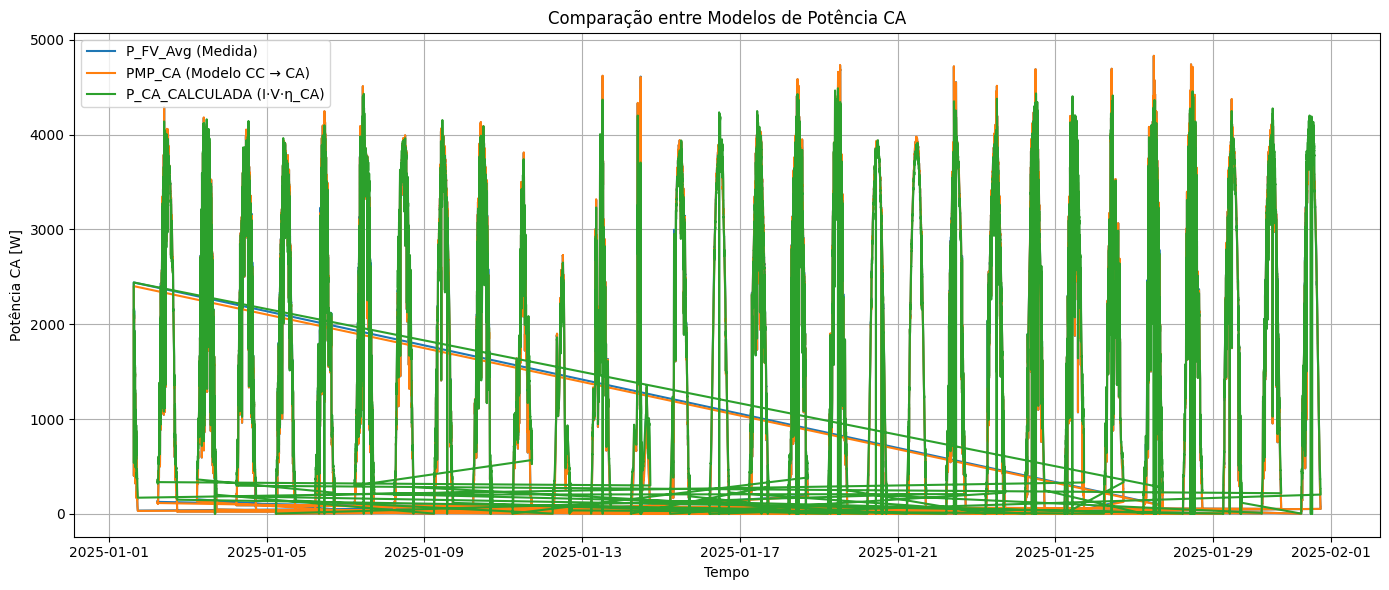

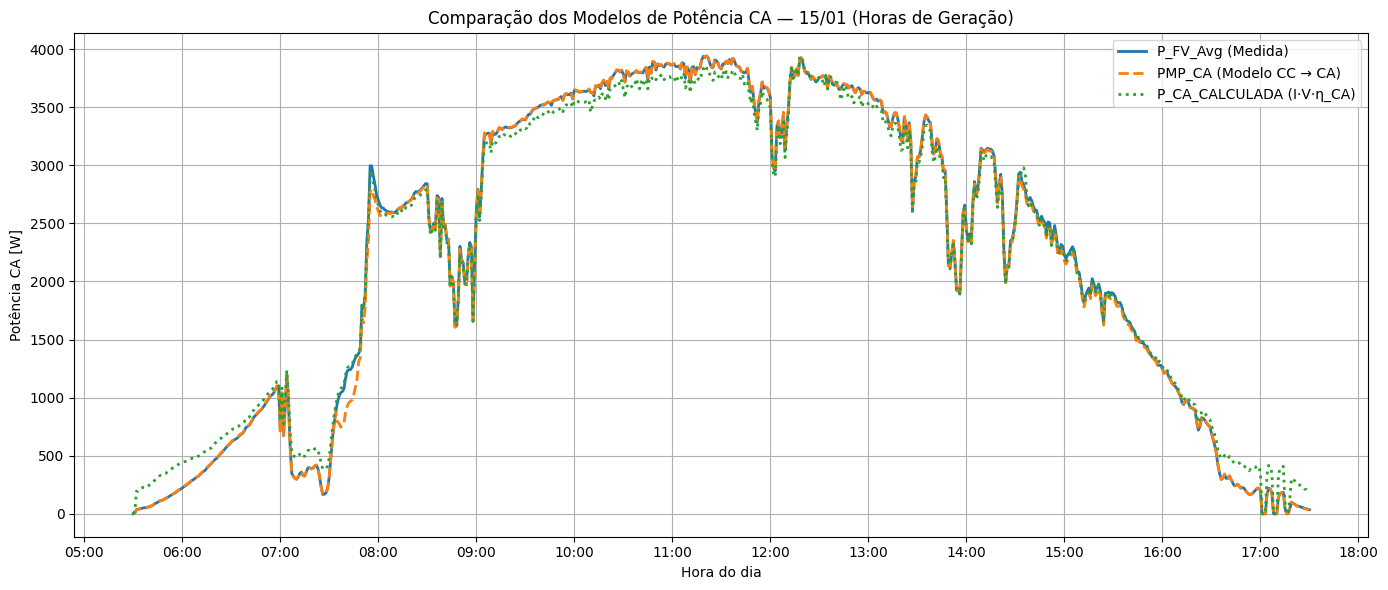

In [24]:
df_dia = df.loc["2025-01-15"]

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["P_FV_Avg"], label="P_FV_Avg (Medida)")
plt.plot(df.index, df["PMP_CA"], label="PMP_CA (Modelo CC → CA)")
plt.plot(df.index, df["P_CA_CALCULADA"], label="P_CA_CALCULADA (I·V·η_CA)")

plt.xlabel("Tempo")
plt.ylabel("Potência CA [W]")
plt.title("Comparação entre Modelos de Potência CA")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.plot(
    df_dia.index,
    df_dia["P_FV_Avg"],
    label="P_FV_Avg (Medida)",
    linewidth=2
)

plt.plot(
    df_dia.index,
    df_dia["PMP_CA"],
    label="PMP_CA (Modelo CC → CA)",
    linestyle="--",
    linewidth=2
)

plt.plot(
    df_dia.index,
    df_dia["P_CA_CALCULADA"],
    label="P_CA_CALCULADA (I·V·η_CA)",
    linestyle=":",
    linewidth=2
)

# ==============================
# FORMATAÇÃO DO EIXO X (HORAS)
# ==============================
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.xlabel("Hora do dia")
plt.ylabel("Potência CA [W]")
plt.title("Comparação dos Modelos de Potência CA — 15/01 (Horas de Geração)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df.index = pd.to_datetime(df.index)
df = df.sort_index()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG1"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.plot(df.index, df["Pmp_STG1_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")

plt.plot(df.index, df["Pmp_STG1_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(0, 1.05 * df[[
    "Potencia_S1_Avg",
    "Pmp_STG1",
    "Pmp_STG1_STC",
    "Pmp_STG1_NOTC"
]].max().max())

plt.title("STRING 1 — Comparação dos Modelos de Potência")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S2_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG2"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.plot(df.index, df["Pmp_STG2_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")

plt.plot(df.index, df["Pmp_STG2_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(0, 1.05 * df[[
    "Potencia_S2_Avg",
    "Pmp_STG2",
    "Pmp_STG2_STC",
    "Pmp_STG2_NOTC"
]].max().max())

plt.title("STRING 2 — Comparação dos Modelos de Potência")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_dia = df.loc["2025-01-15"]

# Mantém apenas instantes com geração efetiva
df_gen = df_dia[df_dia["Radiacao_Avg"] > 10]

plt.figure(figsize=(14,5))

plt.plot(df_gen.index, df_gen["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df_gen.index, df_gen["Pmp_STG1"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.plot(df_gen.index, df_gen["Pmp_STG1_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")

plt.plot(df_gen.index, df_gen["Pmp_STG1_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(
    0,
    1.05 * df_gen[[
        "Potencia_S1_Avg",
        "Pmp_STG1",
        "Pmp_STG1_STC",
        "Pmp_STG1_NOTC"
    ]].max().max()
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("STRING 1 — Modelos de Potência (15/01 — Horas de Geração)")
plt.xlabel("Hora do dia")
plt.ylabel("Potência (W)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
df_dia = df.loc["2025-01-15"]

# Mantém apenas instantes com geração efetiva
df_gen = df_dia[df_dia["Radiacao_Avg"] > 10]

plt.figure(figsize=(14,5))

plt.plot(df_gen.index, df_gen["Potencia_S2_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df_gen.index, df_gen["Pmp_STG2"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.plot(df_gen.index, df_gen["Pmp_STG2_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")

plt.plot(df_gen.index, df_gen["Pmp_STG2_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(
    0,
    1.05 * df_gen[[
        "Potencia_S2_Avg",
        "Pmp_STG2",
        "Pmp_STG2_STC",
        "Pmp_STG2_NOTC"
    ]].max().max()
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("STRING 2 — Modelos de Potência (15/01 — Horas de Geração)")
plt.xlabel("Hora do dia")
plt.ylabel("Potência (W)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# GRÁFICO DA POTÊNCIA IDEAL NO MÊS DE JANEIRO


plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG1"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.ylim(0, 1.05 * df[[
    "Potencia_S1_Avg",
    "Pmp_STG1",
    "Pmp_STG1_STC",
    "Pmp_STG1_NOTC"
]].max().max())

plt.title("STRING 1 — Modelo de Potência Ideal")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG2"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.ylim(0, 1.05 * df[[
    "Potencia_S2_Avg",
    "Pmp_STG2",
    "Pmp_STG2_STC",
    "Pmp_STG2_NOTC"
]].max().max())

plt.title("STRING 2 — Modelo de Potência Ideal")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")


plt.plot(df.index, df["Pmp_STG1_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")


plt.ylim(0, 1.05 * df[[
    "Potencia_S1_Avg",
    "Pmp_STG1",
    "Pmp_STG1_STC",
    "Pmp_STG1_NOTC"
]].max().max())

plt.title("STRING 1 — Modelo de Potência STC")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S2_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG2_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")



plt.ylim(0, 1.05 * df[[
    "Potencia_S2_Avg",
    "Pmp_STG2",
    "Pmp_STG2_STC",
    "Pmp_STG2_NOTC"
]].max().max())

plt.title("STRING 2 — Modelo de Potência STC")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S1_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG1_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(0, 1.05 * df[[
    "Potencia_S1_Avg",
    "Pmp_STG1",
    "Pmp_STG1_STC",
    "Pmp_STG1_NOTC"
]].max().max())

plt.title("STRING 1 — Modelo de Potência NOTC")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Potencia_S2_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df.index, df["Pmp_STG2_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.ylim(0, 1.05 * df[[
    "Potencia_S2_Avg",
    "Pmp_STG2",
    "Pmp_STG2_STC",
    "Pmp_STG2_NOTC"
]].max().max())

plt.title("STRING 2 — Modelo de Potência NOTC")
plt.xlabel("Data")
plt.ylabel("Potência (W)")

# >>> FORMATAÇÃO CORRETA DO EIXO X (DATAS)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df.corr()

In [ ]:
# =========================================================
# REGRESSÃO LINEAR — STRING 1
# =========================================================

from sklearn.linear_model import LinearRegression


X_s1 = df[["Radiacao_Avg", "Temp_Cel_Avg"]]
y_s1 = df["Potencia_S1_Avg"]

dados_s1 = pd.concat([X_s1, y_s1], axis=1).dropna()

modelo_s1 = LinearRegression()
modelo_s1.fit(dados_s1[["Radiacao_Avg","Temp_Cel_Avg"]], dados_s1["Potencia_S1_Avg"])

df["Pmp_STG1_REG"] = modelo_s1.predict(
    df[["Radiacao_Avg","Temp_Cel_Avg"]]
).clip(min=0)

# =========================================================
# REGRESSÃO LINEAR — STRING 2
# =========================================================

X_s2 = df[["Radiacao_Avg", "Temp_Cel_Avg"]]
y_s2 = df["Potencia_S2_Avg"]

dados_s2 = pd.concat([X_s2, y_s2], axis=1).dropna()

modelo_s2 = LinearRegression()
modelo_s2.fit(dados_s2[["Radiacao_Avg","Temp_Cel_Avg"]], dados_s2["Potencia_S2_Avg"])

df["Pmp_STG2_REG"] = modelo_s2.predict(
    df[["Radiacao_Avg","Temp_Cel_Avg"]]
).clip(min=0)

In [ ]:
df_dia = df.loc["2025-01-15"]

# Mantém apenas instantes com geração efetiva
df_gen = df_dia[df_dia["Radiacao_Avg"] > 10]

plt.figure(figsize=(14,5))

plt.plot(df_gen.index, df_gen["Potencia_S2_Avg"],
         color="black", linewidth=2.2, label="Potência Medida")

plt.plot(df_gen.index, df_gen["Pmp_STG2"],
         color="tab:blue", linestyle="--", linewidth=1.8, label="Pmp Ideal")

plt.plot(df_gen.index, df_gen["Pmp_STG2_STC"],
         color="tab:green", linewidth=1.6, label="Pmp STC")

plt.plot(df_gen.index, df_gen["Pmp_STG2_NOTC"],
         color="tab:red", linewidth=1.6, label="Pmp NOTC")

plt.plot(df_gen.index, df_gen["Pmp_STG2_REG"],
         color="yellow", linewidth=1.6, label="Pmp REG")

plt.ylim(
    0,
    1.05 * df_gen[[
        "Potencia_S2_Avg",
        "Pmp_STG2",
        "Pmp_STG2_STC",
        "Pmp_STG2_NOTC"
    ]].max().max()
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("STRING 2 — Modelos de Potência (15/01 — Horas de Geração)")
plt.xlabel("Hora do dia")
plt.ylabel("Potência (W)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
df.to_csv("dados_supervisorio.csv")

In [38]:
!pip install streamlit altair

In [83]:
%%writefile dashboard_fv.py
import time
import numpy as np
import pandas as pd
import streamlit as st
import altair as alt
from sklearn.linear_model import LinearRegression

alt.data_transformers.disable_max_rows()

st.set_page_config(page_title="Supervisório Fotovoltaico", layout="wide")
st.write(
 "Bem-vindo ao dashboard do sistema fotovoltaico. "
 "Use os filtros na barra lateral para analisar os dados.")

# =========================================================
# UTILIDADES
# =========================================================
@st.cache_data
def load_data():

    df_loaded = pd.read_csv("dados_supervisorio.csv", parse_dates=["TMSTAMP"])
    df_loaded = df_loaded.set_index("TMSTAMP")
    df_loaded = df_loaded.sort_index()

    return df_loaded


df = load_data()

# =========================================================
# SIDEBAR
# =========================================================
with st.sidebar:

    st.subheader("Filtros")
    st.header("Supervisório FV - PIBIC 25/26")
    st.image(
        "/content/PIBIC LOGO.jpg",
        width=100
    )

    st.subheader("Filtros")

    st.title("Configurações")

    auto_refresh = st.checkbox("Atualização automática (Tempo Real)", value=False)
    refresh_sec = st.slider("Intervalo (s)", 5, 60, 10)

    st.subheader("Filtro de datas")

    start_date = st.date_input("Data inicial", df.index.min().date())
    end_date = st.date_input("Data final", df.index.max().date())

    mask = (df.index.date >= start_date) & (df.index.date <= end_date)
    df = df.loc[mask]

st.title("Supervisório de Monitoramento Fotovoltaico")

# =========================================================
# FUNÇÕES
# =========================================================
def metricas_erro(y_medido, y_modelo):

    mask = (y_medido > 0) & (~y_medido.isna()) & (~y_modelo.isna())

    y_medido = y_medido[mask].values
    y_modelo = y_modelo[mask].values

    if len(y_medido) == 0:
        return np.nan, np.nan, np.nan, np.nan

    mse = np.mean((y_medido - y_modelo) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_medido - y_modelo))
    mape = np.mean(np.abs((y_medido - y_modelo) / y_medido)) * 100

    return mse, rmse, mae, mape


def treinar_regressao_cc(df, col_y):

    X = df[["Radiacao_Avg", "Temp_Cel_Avg"]]
    y = df[col_y]

    dados = pd.concat([X, y], axis=1).dropna()

    if len(dados) < 10:
        return None

    model = LinearRegression()
    model.fit(dados[["Radiacao_Avg","Temp_Cel_Avg"]], dados[col_y])

    return model


def treinar_regressao_ca(df):

    X = df[["Radiacao_Avg","Temp_Cel_Avg","Potencia_S1_S2_Avg"]]
    y = df["P_FV_Avg"]

    dados = pd.concat([X, y], axis=1).dropna()

    if len(dados) < 10:
        return None

    model = LinearRegression()
    model.fit(dados[["Radiacao_Avg","Temp_Cel_Avg","Potencia_S1_S2_Avg"]], dados["P_FV_Avg"])

    return model


# =========================================================
# MODELOS
# =========================================================
if "Pmp_STG1_REG" not in df.columns:

    m1 = treinar_regressao_cc(df, "Potencia_S1_Avg")

    if m1 is not None:
        df["Pmp_STG1_REG"] = m1.predict(df[["Radiacao_Avg","Temp_Cel_Avg"]]).clip(0)


if "Pmp_STG2_REG" not in df.columns:

    m2 = treinar_regressao_cc(df, "Potencia_S2_Avg")

    if m2 is not None:
        df["Pmp_STG2_REG"] = m2.predict(df[["Radiacao_Avg","Temp_Cel_Avg"]]).clip(0)


if "P_CA_REG" not in df.columns:

    mca = treinar_regressao_ca(df)

    if mca is not None:
        df["P_CA_REG"] = mca.predict(df[["Radiacao_Avg","Temp_Cel_Avg","Potencia_S1_S2_Avg"]]).clip(0)

df_plot = df.reset_index()

# =========================================================
# ABAS
# =========================================================
aba1, aba2, aba3, aba4, aba5, aba6 = st.tabs([
    "Resumo do Sistema",
    "Monitoramento CC",
    "Monitoramento CA",
    "Comparação de Modelos",
    "Diagnóstico e Alertas",
    "Tempo Real"
])

# =========================================================
# 1 RESUMO
# =========================================================
with aba1:

    st.subheader("Indicadores gerais")

    ultimo = df.iloc[-1]

    c1, c2, c3, c4 = st.columns(4)

    c1.metric("Potência CA", f"{ultimo.get('P_FV_Avg', np.nan):.1f} W")
    c2.metric("Radiação", f"{ultimo.get('Radiacao_Avg', np.nan):.1f} W/m²")
    c3.metric("Temp. Célula", f"{ultimo.get('Temp_Cel_Avg', np.nan):.1f} °C")
    c4.metric("Demanda", f"{ultimo.get('Demanda_Avg', np.nan):.1f} W")

    cols = ["P_FV_Avg","Potencia_S1_S2_Avg"]
    cols = [c for c in cols if c in df.columns]

    df_long = df_plot.melt(
        id_vars="TMSTAMP",
        value_vars=cols,
        var_name="Variavel",
        value_name="Valor"
    )

    chart = alt.Chart(df_long).mark_line().encode(
        x="TMSTAMP:T",
        y="Valor:Q",
        color="Variavel:N",
        tooltip=["TMSTAMP:T","Variavel:N","Valor:Q"]
    ).interactive()

    st.altair_chart(chart, use_container_width=True)

# =========================================================
# 2 MONITORAMENTO CC
# =========================================================
with aba2:

    st.subheader("Strings fotovoltaicas")

    col = st.selectbox("Selecionar String", ["S1","S2"])

    if col == "S1":
        y_cols = ["Potencia_S1_Avg","Pmp_STG1","Pmp_STG1_STC","Pmp_STG1_NOTC","Pmp_STG1_REG"]
    else:
        y_cols = ["Potencia_S2_Avg","Pmp_STG2","Pmp_STG2_STC","Pmp_STG2_NOTC","Pmp_STG2_REG"]

    y_cols = [c for c in y_cols if c in df.columns]

    df_long = df_plot.melt(
        id_vars="TMSTAMP",
        value_vars=y_cols,
        var_name="Modelo",
        value_name="Potencia"
    )

    chart = alt.Chart(df_long).mark_line().encode(
        x="TMSTAMP:T",
        y="Potencia:Q",
        color="Modelo:N",
        tooltip=["TMSTAMP:T","Modelo:N","Potencia"]
    ).interactive()

    st.altair_chart(chart, use_container_width=True)

# =========================================================
# 3 MONITORAMENTO CA
# =========================================================
with aba3:

    st.subheader("Potência CA")

    y_cols = ["P_FV_Avg","PMP_CA","P_CA_CALCULADA","P_CA_REG"]
    y_cols = [c for c in y_cols if c in df.columns]

    df_long = df_plot.melt(
        id_vars="TMSTAMP",
        value_vars=y_cols,
        var_name="Modelo",
        value_name="Potencia"
    )

    chart = alt.Chart(df_long).mark_line().encode(
        x="TMSTAMP:T",
        y="Potencia:Q",
        color="Modelo:N",
        tooltip=["TMSTAMP:T","Modelo:N","Potencia"]
    ).interactive()

    st.altair_chart(chart, use_container_width=True)

# =========================================================
# 4 COMPARAÇÃO
# =========================================================
with aba4:

    st.subheader("Métricas de erro")

    linhas = []

    if "PMP_CA" in df.columns:
        linhas.append(["CA","Modelo PMP", *metricas_erro(df["P_FV_Avg"], df["PMP_CA"])])

    if "P_CA_CALCULADA" in df.columns:
        linhas.append(["CA","Modelo Elétrico", *metricas_erro(df["P_FV_Avg"], df["P_CA_CALCULADA"])])

    if "P_CA_REG" in df.columns:
        linhas.append(["CA","Regressão", *metricas_erro(df["P_FV_Avg"], df["P_CA_REG"])])

    tabela = pd.DataFrame(linhas, columns=["Sistema","Modelo","MSE","RMSE","MAE","MAPE (%)"])

    st.dataframe(tabela)

# =========================================================
# 5 ALERTAS
# =========================================================
with aba5:

    st.subheader("Detecção simples de anomalias")

    if "PMP_CA" in df.columns:

        erro = (df["P_FV_Avg"] - df["PMP_CA"]) / df["P_FV_Avg"]
        df["erro_relativo"] = erro

        alertas = df[np.abs(erro) > 0.25]

        st.write("Eventos com erro > 25%")
        st.dataframe(alertas.tail(20))

# =========================================================
# 6 TEMPO REAL
# =========================================================
with aba6:

    st.subheader("Monitoramento em tempo real")

    ultimo = df.iloc[-1]

    col1, col2, col3 = st.columns(3)

    col1.metric("Potência CA", f"{ultimo.get('P_FV_Avg', np.nan):.1f} W")
    col2.metric("Radiação", f"{ultimo.get('Radiacao_Avg', np.nan):.1f} W/m²")
    col3.metric("Temperatura", f"{ultimo.get('Temp_Cel_Avg', np.nan):.1f} °C")

    df_temp = df.tail(100).reset_index()

    chart = alt.Chart(df_temp).mark_line().encode(
        x="TMSTAMP:T",
        y="P_FV_Avg:Q",
        tooltip=["TMSTAMP:T","P_FV_Avg"]
    ).interactive()

    st.altair_chart(chart, use_container_width=True)

# =========================================================
# AUTO REFRESH
# =========================================================
if auto_refresh:

    time.sleep(refresh_sec)
    st.rerun()

Overwriting dashboard_fv.py


In [29]:
from pyngrok import ngrok
!streamlit run dashboard_fv.py &>/dev/null &
public_url = ngrok.connect(8501)
print(public_url)


!ngrok config add-authtoken 3AfcjLazkxFJWWpxSQICjIMVczF_7NvWitoCDt692An4kGRYY


NgrokTunnel: "https://undecidedly-dosimetric-kirk.ngrok-free.dev" -> "http://localhost:8501"
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
## RESETAR O CÓDIGO

!killall streamlit